# Executive_Dashboard

C:\Users\HUU THUC\AppData\Local\Temp\ipykernel_4004\2750571847.py:37: DtypeWarning: Columns (0: order_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(fact_path)


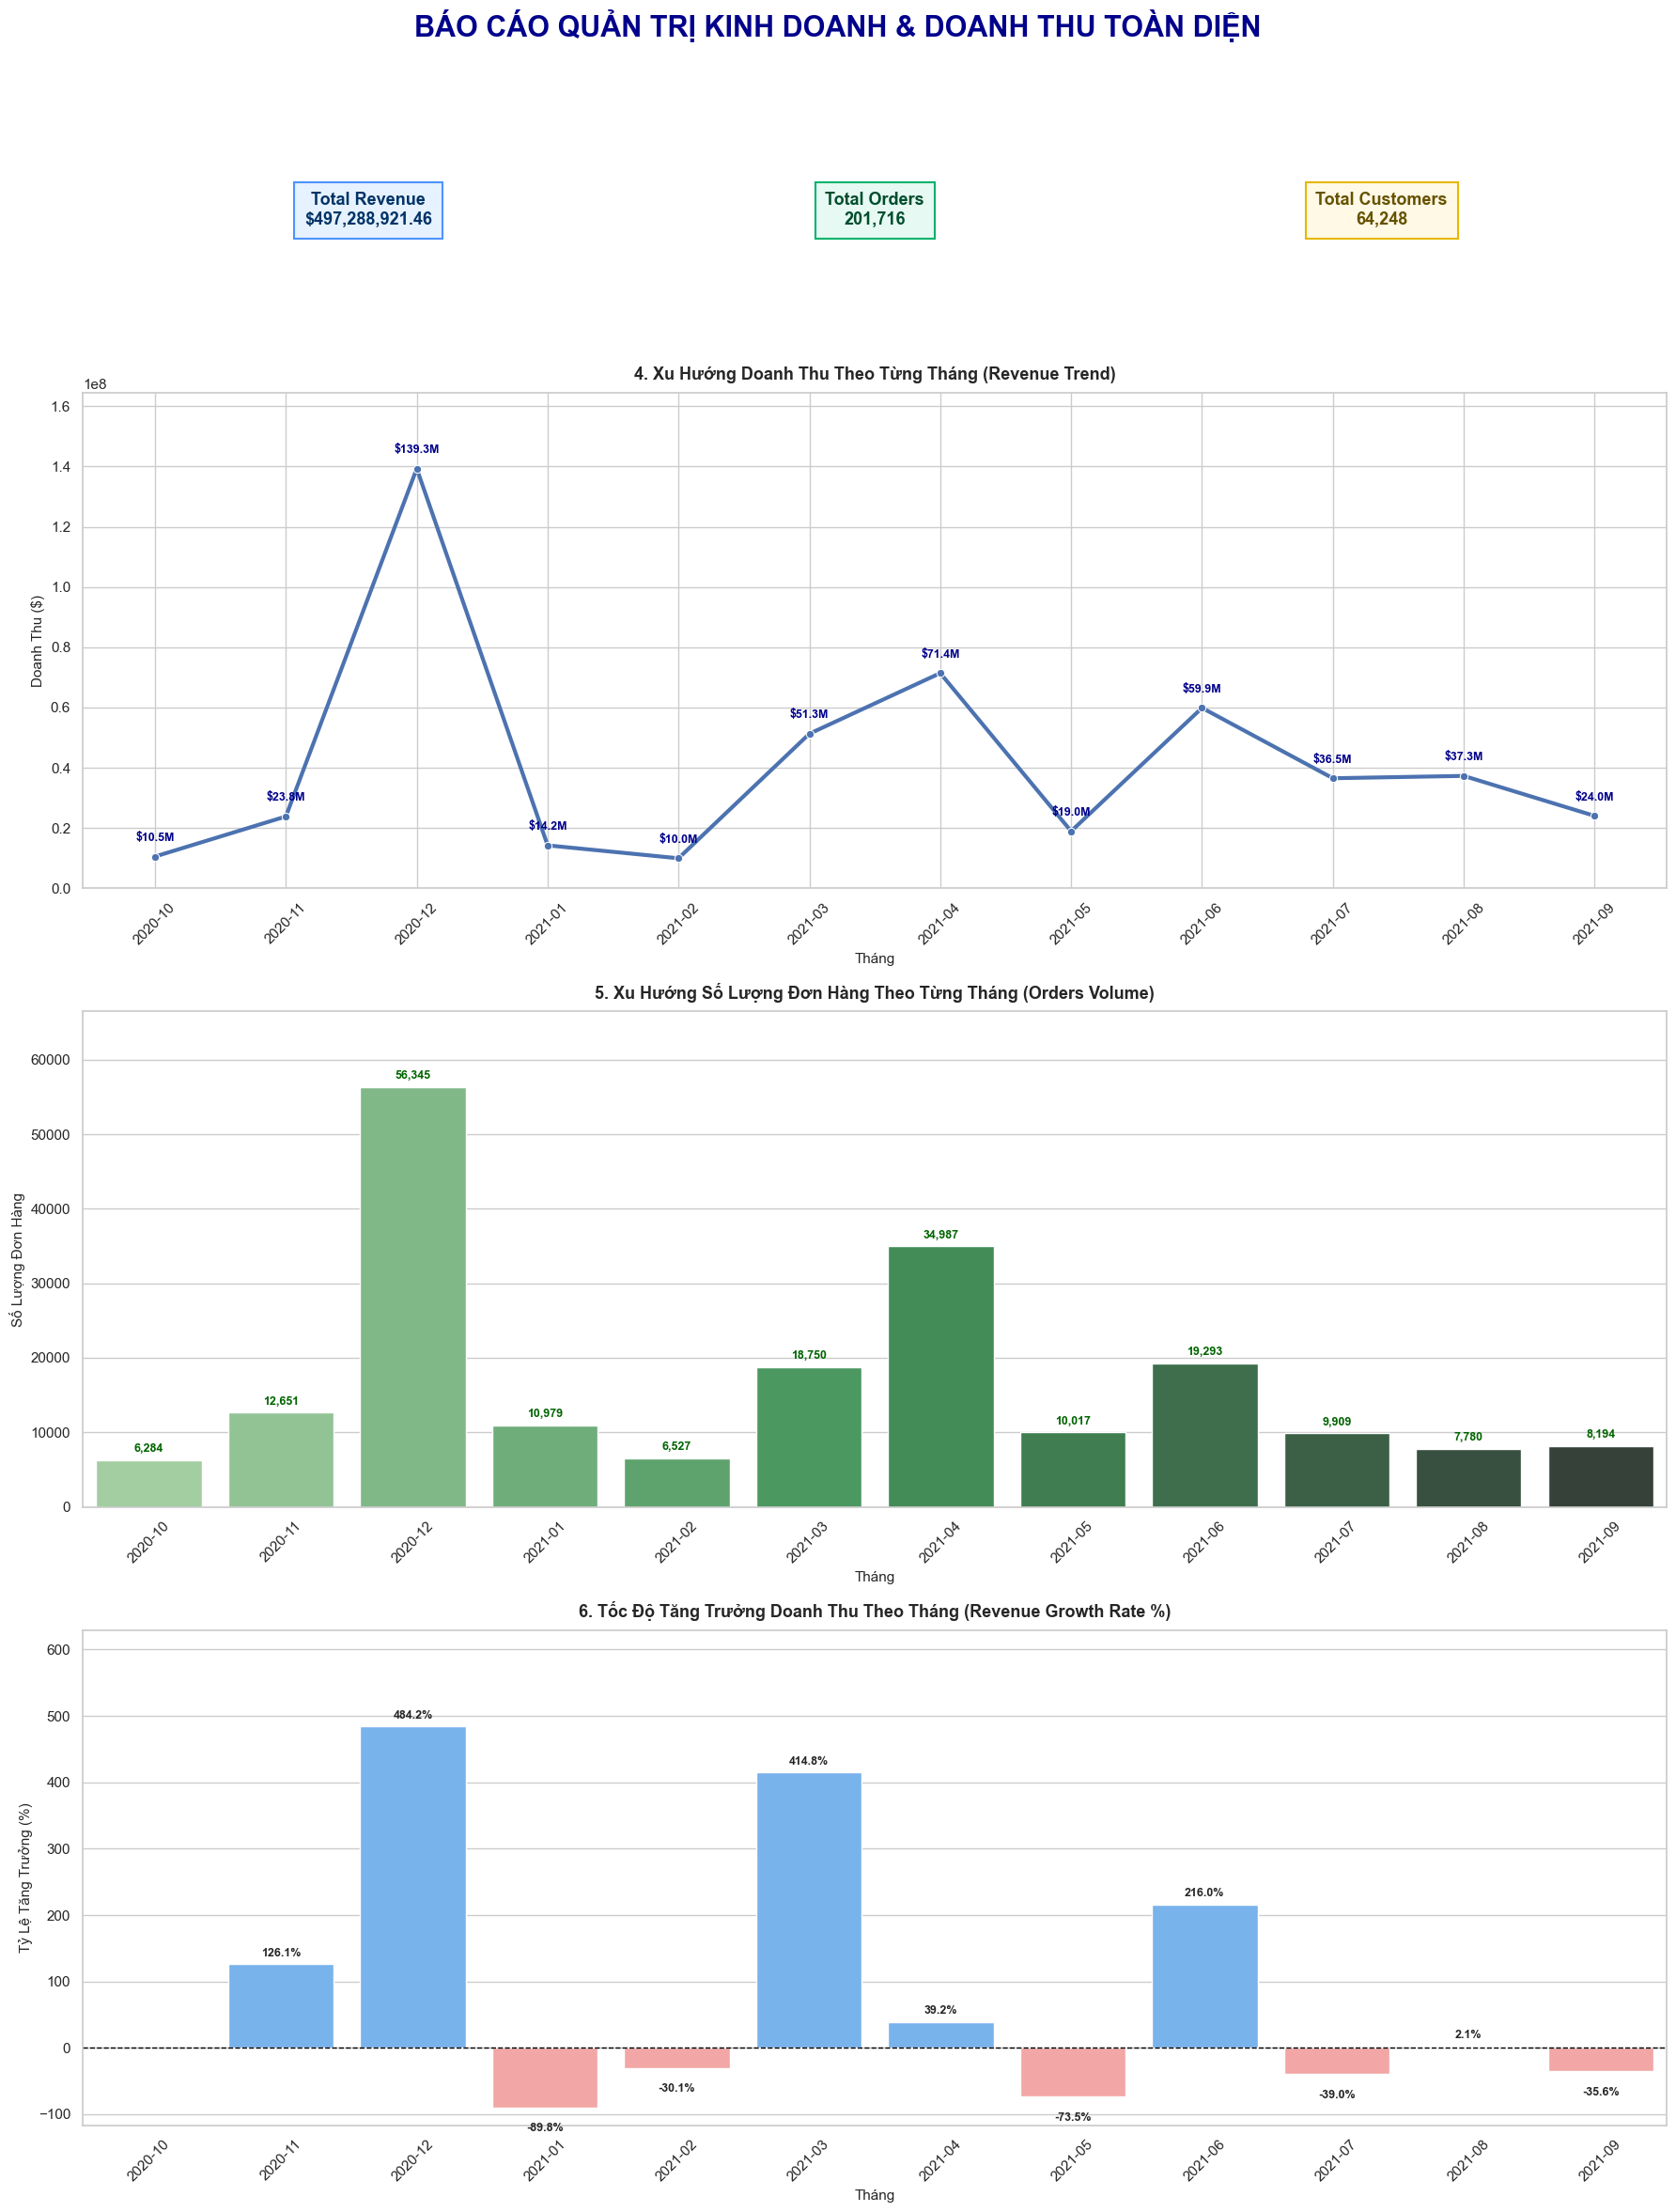

In [12]:
# ############################################################################
# EXECUTIVE DASHBOARD: TỔNG QUAN HOẠT ĐỘNG KINH DOANH & DOANH THU (HOÀN CHỈNH)
# Sinh viên thực hiện: Nguyễn Hữu Thức  
# Trường: FPT Polytechnic (Ho Chi Minh City)  
# ############################################################################

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. CẤU HÌNH GIAO DIỆN CHUNG
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# Tạo một khung hình lớn tích hợp toàn bộ Dashboard (KPI Cards + Biểu đồ)
fig = plt.figure(figsize=(18, 24))
fig.suptitle('BÁO CÁO QUẢN TRỊ KINH DOANH & DOANH THU TOÀN DIỆN', 
             fontsize=22, fontweight='bold', color='darkblue', y=0.98)

# Thiết lập GridSpec: Chia làm 4 tầng dòng (Tầng 0 làm KPI Cards, Tầng 1, 2, 3 làm 3 biểu đồ)
gs = fig.add_gridspec(4, 1, height_ratios=[0.3, 1, 1, 1])

ax_kpi = fig.add_subplot(gs[0])  # Vùng chứa 3 KPI Cards
ax4    = fig.add_subplot(gs[1])  # Vùng chứa Mục 4: Revenue Trend
ax5    = fig.add_subplot(gs[2])  # Vùng chứa Mục 5: Orders Volume
ax6    = fig.add_subplot(gs[3])  # Vùng chứa Mục 6: Revenue Growth Rate %


# 2. ĐỌC VÀ XỬ LÝ DỮ LIỆU TỪ FILE GỐC TRONG DỰ ÁN
fact_path = "E:/Dự Án Tốt Nghiệp/PRO2291_duantotnghiep1/data/dim_fact/fact_sales.csv"

# Nếu chạy trên notebook trong thư mục trực quan, tự động ưu tiên đường dẫn tương đối
if not os.path.exists(fact_path):
    fact_path = "../../data/dim_fact/fact_sales.csv"

df_raw = pd.read_csv(fact_path)

# Tự động dò tìm tên cột chứa ngày tháng trong file dữ liệu của bạn
possible_date_cols = ['order_date', 'Order Date', 'date', 'Date', 'sales_date']
date_col = next((col for col in df_raw.columns if col in possible_date_cols), None)
if date_col is None:
    date_col = next((col for col in df_raw.columns if 'date' in col.lower() or 'month' in col.lower()), df_raw.columns[0])

# Ép kiểu chuỗi thô để Pandas tự động nhận diện ngày tháng chuẩn xác (Sửa lỗi dồn mốc 1970)
df_raw[date_col] = df_raw[date_col].astype(str)
df_raw['clean_date'] = pd.to_datetime(df_raw[date_col], errors='coerce')

# Dự phòng nếu dữ liệu chỉ chứa chuỗi tháng viết tắt dạng 'Jul-20', 'Aug-20'
if df_raw['clean_date'].isna().sum() == len(df_raw):
    df_raw['clean_date'] = pd.to_datetime(df_raw[date_col], format='%b-%y', errors='coerce')

# Lọc bỏ dòng lỗi/rỗng ngày tháng nếu có
df_raw = df_raw.dropna(subset=['clean_date'])

# Định dạng nhãn trục hoành theo tiến trình thời gian tăng dần 'YYYY-MM'
df_raw['year_month'] = df_raw['clean_date'].dt.to_period('M')

# Làm sạch cột doanh thu (revenue) đưa về dạng số
if df_raw['revenue'].dtype == 'object':
    df_raw['revenue'] = df_raw['revenue'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df_raw['revenue'] = pd.to_numeric(df_raw['revenue'], errors='coerce')


# ----------------------------------------------------------------------------
# 3. TÍNH TOÁN CÁC CHỈ SỐ KPI CHIẾN LƯỢC (MỤC 1, 2, 3)
# ----------------------------------------------------------------------------
# 1. KPI Total Revenue
total_revenue = df_raw['revenue'].sum()

# 2. KPI Total Orders
order_col = 'order_id' if 'order_id' in df_raw.columns else ('id' if 'id' in df_raw.columns else df_raw.columns[0])
total_orders = df_raw[order_col].nunique()

# 3. KPI Total Customers
customer_col = 'customer_id' if 'customer_id' in df_raw.columns else 'customer'
total_customers = df_raw[customer_col].nunique()

# GOM NHÓM DỮ LIỆU ĐỂ PHỤC VỤ VẼ CÁC BIỂU ĐỒ 4, 5, 6
df_monthly = df_raw.groupby('year_month').agg(
    revenue=('revenue', 'sum'),
    orders=(order_col, 'nunique')
).reset_index()

# Sắp xếp tuyến tính theo chuỗi thời gian tăng dần
df_monthly = df_monthly.sort_values('year_month').reset_index(drop=True)
df_monthly['month_label'] = df_monthly['year_month'].astype(str)

# 6. Tính toán tỷ lệ phần trăm tăng trưởng doanh thu (Revenue Growth Rate %)
df_monthly['revenue_growth_rate'] = df_monthly['revenue'].pct_change() * 100


# ============================================================================
# PHẦN VẼ 1: 3 KPI CARDS ĐÓNG KHUNG TRỰC QUAN (TẦNG TRÊN CÙNG)
# ============================================================================
ax_kpi.axis('off')  # Ẩn hệ trục tọa độ của vùng chứa Card

# Định hình màu sắc và đường viền cho từng thẻ Card độc lập
card_style_1 = dict(boxstyle="square,pad=0.6", facecolor="#e6f2ff", edgecolor="#4d94ff", linewidth=1.5) # Xanh dương
card_style_2 = dict(boxstyle="square,pad=0.6", facecolor="#e6f9f2", edgecolor="#00b36b", linewidth=1.5) # Xanh lá
card_style_3 = dict(boxstyle="square,pad=0.6", facecolor="#fff9e6", edgecolor="#e6b800", linewidth=1.5) # Vàng

# Gán văn bản và số liệu định dạng
text_revenue = f"Total Revenue\n${total_revenue:,.2f}"
text_orders = f"Total Orders\n{total_orders:,}"
text_customers = f"Total Customers\n{total_customers:,}"

# Phân bổ vị trí cân đối theo trục ngang
ax_kpi.text(0.18, 0.4, text_revenue, transform=ax_kpi.transAxes, fontsize=13, fontweight='bold', ha='center', va='center', color='#003366', bbox=card_style_1)
ax_kpi.text(0.50, 0.4, text_orders, transform=ax_kpi.transAxes, fontsize=13, fontweight='bold', ha='center', va='center', color='#004d2e', bbox=card_style_2)
ax_kpi.text(0.82, 0.4, text_customers, transform=ax_kpi.transAxes, fontsize=13, fontweight='bold', ha='center', va='center', color='#665200', bbox=card_style_3)


# ============================================================================
# MỤC 4: REVENUE TREND BY MONTH (XU HƯỚNG DOANH THU - BIỂU ĐỒ ĐƯỜNG LINE)
# ============================================================================
sns.lineplot(data=df_monthly, x='month_label', y='revenue', marker='o', color='b', linewidth=3, ax=ax4)
ax4.set_title('4. Xu Hướng Doanh Thu Theo Từng Tháng (Revenue Trend)', fontsize=13, fontweight='bold', pad=10)
ax4.set_xlabel('Tháng', fontsize=11)
ax4.set_ylabel('Doanh Thu ($)', fontsize=11)
ax4.tick_params(axis='x', rotation=45)

offset_rev = df_monthly['revenue'].max() * 0.03 if len(df_monthly) > 0 else 1
for i in range(len(df_monthly)):
    row = df_monthly.iloc[i]
    if pd.notna(row['revenue']) and row['revenue'] > 0:
        ax4.text(x=row['month_label'], y=row['revenue'] + offset_rev, 
                 s=f"${row['revenue']/1000000:.1f}M", ha='center', va='bottom', fontsize=9, fontweight='bold', color='darkblue')
ax4.set_ylim(0, df_monthly['revenue'].max() * 1.18 if len(df_monthly) > 0 else 100)


# ============================================================================
# MỤC 5: ORDERS TREND BY MONTH (XU HƯỚNG ĐƠN HÀNG - BIỂU ĐỒ CỘT COLUMN)
# ============================================================================
sns.barplot(data=df_monthly, x='month_label', y='orders', hue='month_label', palette='Greens_d', legend=False, ax=ax5)
ax5.set_title('5. Xu Hướng Số Lượng Đơn Hàng Theo Từng Tháng (Orders Volume)', fontsize=13, fontweight='bold', pad=10)
ax5.set_xlabel('Tháng', fontsize=11)
ax5.set_ylabel('Số Lượng Đơn Hàng', fontsize=11)
ax5.tick_params(axis='x', rotation=45)

for p in ax5.patches:
    val = p.get_height()
    if pd.notna(val) and val > 0:
        ax5.annotate(f"{int(val):,}", (p.get_x() + p.get_width() / 2., val), 
                     ha='center', va='bottom', fontsize=9, fontweight='bold', color='darkgreen', xytext=(0, 4), textcoords='offset points')
ax5.set_ylim(0, df_monthly['orders'].max() * 1.18 if len(df_monthly) > 0 else 100)


# ============================================================================
# MỤC 6: REVENUE GROWTH RATE (%) (TỐC ĐỘ TĂNG TRƯỞNG - BIỂU ĐỒ CỘT BAR ÂM DƯƠNG)
# ============================================================================
colors = ['#ff9999' if x < 0 else '#66b3ff' for x in df_monthly['revenue_growth_rate'].fillna(0)]
sns.barplot(data=df_monthly, x='month_label', y='revenue_growth_rate', hue='month_label', palette=colors, legend=False, ax=ax6)

ax6.axhline(0, color='black', linewidth=1, linestyle='--')
ax6.set_title('6. Tốc Độ Tăng Trưởng Doanh Thu Theo Tháng (Revenue Growth Rate %)', fontsize=13, fontweight='bold', pad=10)
ax6.set_xlabel('Tháng', fontsize=11)
ax6.set_ylabel('Tỷ Lệ Tăng Trưởng (%)', fontsize=11)
ax6.tick_params(axis='x', rotation=45)

for p in ax6.patches:
    val = p.get_height()
    if pd.notna(val) and val != 0:
        va_dir = 'bottom' if val >= 0 else 'top'
        xy_dir = (0, 4) if val >= 0 else (0, -12)
        ax6.annotate(f"{val:.1f}%", (p.get_x() + p.get_width() / 2., val), 
                     ha='center', va=va_dir, fontsize=9, fontweight='bold', xytext=xy_dir, textcoords='offset points')

y_max = df_monthly['revenue_growth_rate'].max() if len(df_monthly) > 0 else 10
y_min = df_monthly['revenue_growth_rate'].min() if len(df_monthly) > 0 else -10
ax6.set_ylim(y_min * 1.3 if y_min < 0 else -10, y_max * 1.3 if y_max > 0 else 10)


# 4. KẾT XUẤT VÀ HIỂN THỊ
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Biểu đồ 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Cấu hình giao diện chung
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# Đọc dữ liệu chi tiết
fact_path = "E:/Dự Án Tốt Nghiệp/PRO2291_duantotnghiep1/data/dim_fact/fact_sales.csv"
if not os.path.exists(fact_path):
    fact_path = "../../data/dim_fact/fact_sales.csv"

df_raw = pd.read_csv(fact_path)

# Tìm cột ngày tháng
possible_date_cols = ['order_date', 'Order Date', 'date', 'Date', 'sales_date']
date_col = next((col for col in df_raw.columns if col in possible_date_cols), None)
if date_col is None:
    date_col = next((col for col in df_raw.columns if 'date' in col.lower() or 'month' in col.lower()), df_raw.columns[0])

# Chuẩn hóa thời gian và doanh thu
df_raw[date_col] = df_raw[date_col].astype(str)
df_raw['clean_date'] = pd.to_datetime(df_raw[date_col], errors='coerce')
if df_raw['clean_date'].isna().sum() == len(df_raw):
    df_raw['clean_date'] = pd.to_datetime(df_raw[date_col], format='%b-%y', errors='coerce')

df_raw = df_raw.dropna(subset=['clean_date'])
df_raw['year_month'] = df_raw['clean_date'].dt.to_period('M')

if df_raw['revenue'].dtype == 'object':
    df_raw['revenue'] = df_raw['revenue'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df_raw['revenue'] = pd.to_numeric(df_raw['revenue'], errors='coerce')

# Định danh cột đơn hàng
order_col = 'order_id' if 'order_id' in df_raw.columns else ('id' if 'id' in df_raw.columns else df_raw.columns[0])

# Gom nhóm dữ liệu theo tháng
df_monthly = df_raw.groupby('year_month').agg(
    revenue=('revenue', 'sum'),
    orders=(order_col, 'nunique')
).reset_index()

df_monthly = df_monthly.sort_values('year_month').reset_index(drop=True)
df_monthly['month_label'] = df_monthly['year_month'].astype(str)
df_monthly['revenue_growth_rate'] = df_monthly['revenue'].pct_change() * 100

print("-> Chuẩn bị dữ liệu hoàn tất! Bạn có thể chạy các biểu đồ bên dưới.")

-> Chuẩn bị dữ liệu hoàn tất! Bạn có thể chạy các biểu đồ bên dưới.


C:\Users\HUU THUC\AppData\Local\Temp\ipykernel_30188\712737123.py:15: DtypeWarning: Columns (0: order_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(fact_path)


## Biểu đồ 1

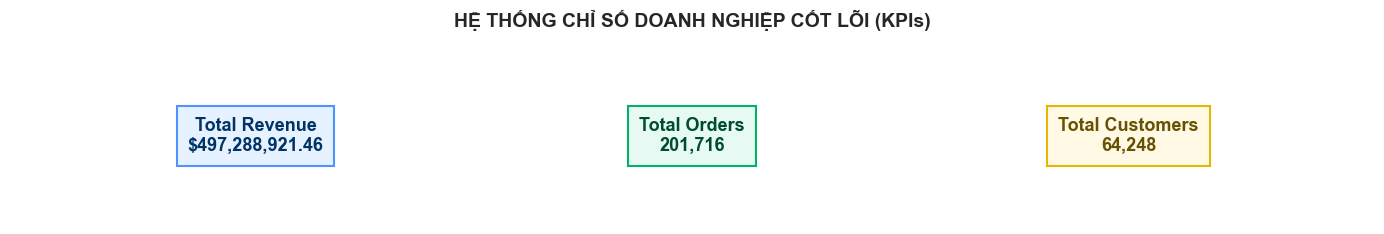

In [8]:
fig, ax = plt.subplots(figsize=(14, 2.5))
ax.axis('off')

# Tính toán giá trị tổng quan
total_revenue = df_raw['revenue'].sum()
total_orders = df_raw[order_col].nunique()
total_customers = df_raw['customer_id'].nunique() if 'customer_id' in df_raw.columns else df_raw[df_raw.columns[0]].nunique()

card_style_1 = dict(boxstyle="square,pad=0.6", facecolor="#e6f2ff", edgecolor="#4d94ff", linewidth=1.5)
card_style_2 = dict(boxstyle="square,pad=0.6", facecolor="#e6f9f2", edgecolor="#00b36b", linewidth=1.5)
card_style_3 = dict(boxstyle="square,pad=0.6", facecolor="#fff9e6", edgecolor="#e6b800", linewidth=1.5)

ax.text(0.18, 0.5, f"Total Revenue\n${total_revenue:,.2f}", transform=ax.transAxes, fontsize=13, fontweight='bold', ha='center', va='center', color='#003366', bbox=card_style_1)
ax.text(0.50, 0.5, f"Total Orders\n{total_orders:,}", transform=ax.transAxes, fontsize=13, fontweight='bold', ha='center', va='center', color='#004d2e', bbox=card_style_2)
ax.text(0.82, 0.5, f"Total Customers\n{total_customers:,}", transform=ax.transAxes, fontsize=13, fontweight='bold', ha='center', va='center', color='#665200', bbox=card_style_3)

plt.title('HỆ THỐNG CHỈ SỐ DOANH NGHIỆP CỐT LÕI (KPIs)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## Biểu đồ 2

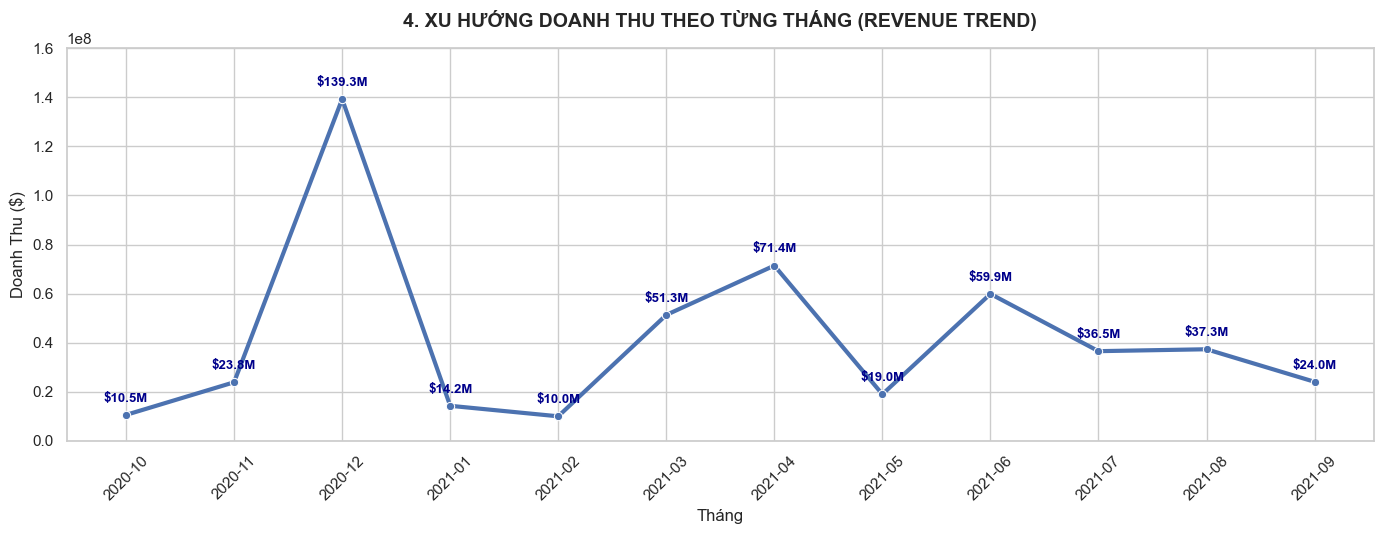

In [9]:
plt.figure(figsize=(14, 5.5))
sns.lineplot(data=df_monthly, x='month_label', y='revenue', marker='o', color='b', linewidth=3)

plt.title('4. XU HƯỚNG DOANH THU THEO TỪNG THÁNG (REVENUE TREND)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Doanh Thu ($)', fontsize=12)
plt.xticks(rotation=45)

offset_rev = df_monthly['revenue'].max() * 0.03
for i in range(len(df_monthly)):
    row = df_monthly.iloc[i]
    if pd.notna(row['revenue']) and row['revenue'] > 0:
        plt.text(x=row['month_label'], y=row['revenue'] + offset_rev, 
                 s=f"${row['revenue']/1000000:.1f}M", ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='darkblue')

plt.ylim(0, df_monthly['revenue'].max() * 1.15)
plt.tight_layout()
plt.show()

## Biểu đồ 3

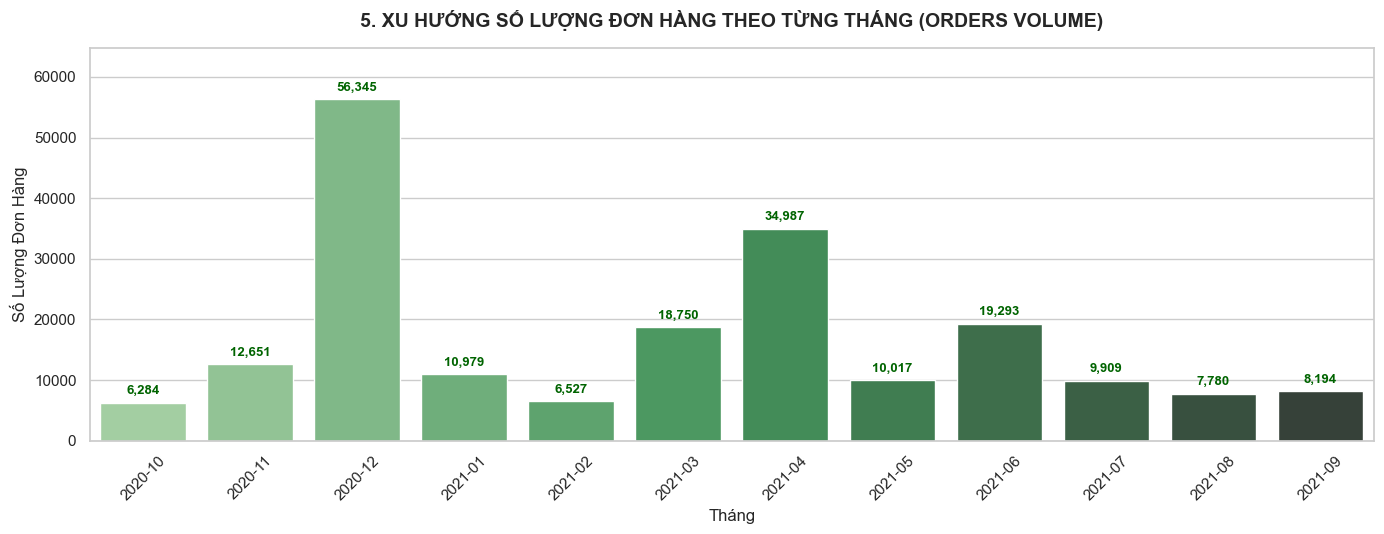

In [10]:
plt.figure(figsize=(14, 5.5))
ax = sns.barplot(data=df_monthly, x='month_label', y='orders', hue='month_label', palette='Greens_d', legend=False)

plt.title('5. XU HƯỚNG SỐ LƯỢNG ĐƠN HÀNG THEO TỪNG THÁNG (ORDERS VOLUME)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Số Lượng Đơn Hàng', fontsize=12)
plt.xticks(rotation=45)

for p in ax.patches:
    val = p.get_height()
    if pd.notna(val) and val > 0:
        ax.annotate(f"{int(val):,}", (p.get_x() + p.get_width() / 2., val), 
                     ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='darkgreen', xytext=(0, 4), textcoords='offset points')

plt.ylim(0, df_monthly['orders'].max() * 1.15)
plt.tight_layout()
plt.show()

## Biểu đồ 4

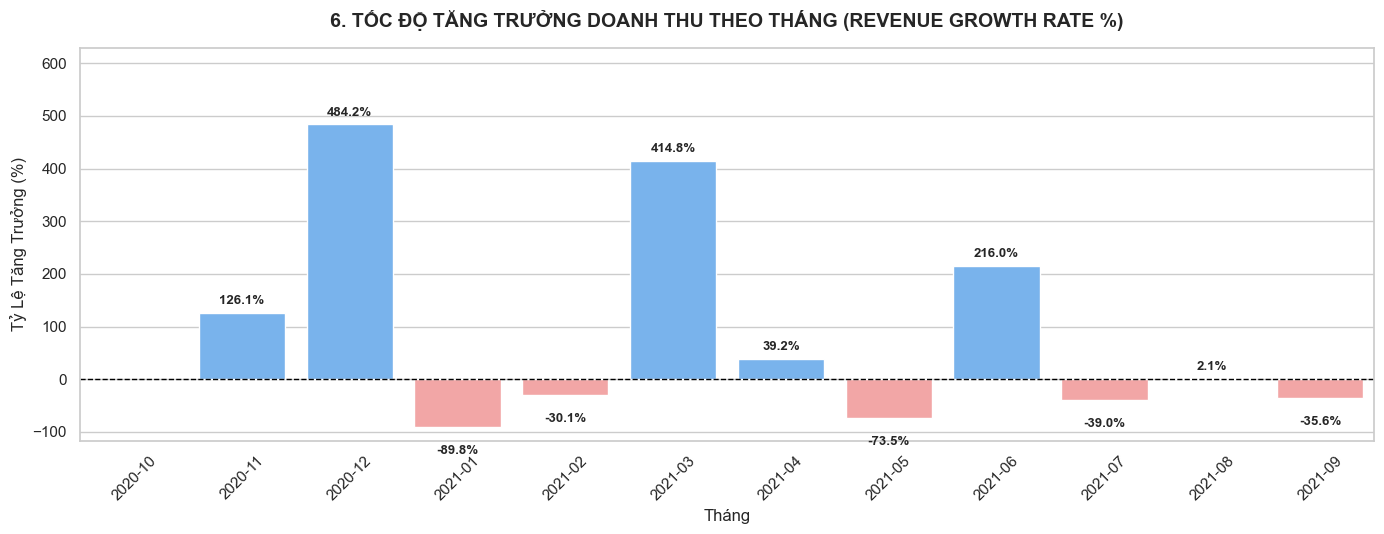

In [11]:
plt.figure(figsize=(14, 5.5))
colors = ['#ff9999' if x < 0 else '#66b3ff' for x in df_monthly['revenue_growth_rate'].fillna(0)]
ax = sns.barplot(data=df_monthly, x='month_label', y='revenue_growth_rate', hue='month_label', palette=colors, legend=False)

plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.title('6. TỐC ĐỘ TĂNG TRƯỞNG DOANH THU THEO THÁNG (REVENUE GROWTH RATE %)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Tỷ Lệ Tăng Trưởng (%)', fontsize=12)
plt.xticks(rotation=45)

for p in ax.patches:
    val = p.get_height()
    if pd.notna(val) and val != 0:
        va_dir = 'bottom' if val >= 0 else 'top'
        xy_dir = (0, 4) if val >= 0 else (0, -13)
        ax.annotate(f"{val:.1f}%", (p.get_x() + p.get_width() / 2., val), 
                     ha='center', va=va_dir, fontsize=9.5, fontweight='bold', xytext=xy_dir, textcoords='offset points')

y_max = df_monthly['revenue_growth_rate'].max()
y_min = df_monthly['revenue_growth_rate'].min()
plt.ylim(y_min * 1.3 if y_min < 0 else -10, y_max * 1.3 if y_max > 0 else 10)

plt.tight_layout()
plt.show()

## Biểu đồ 5

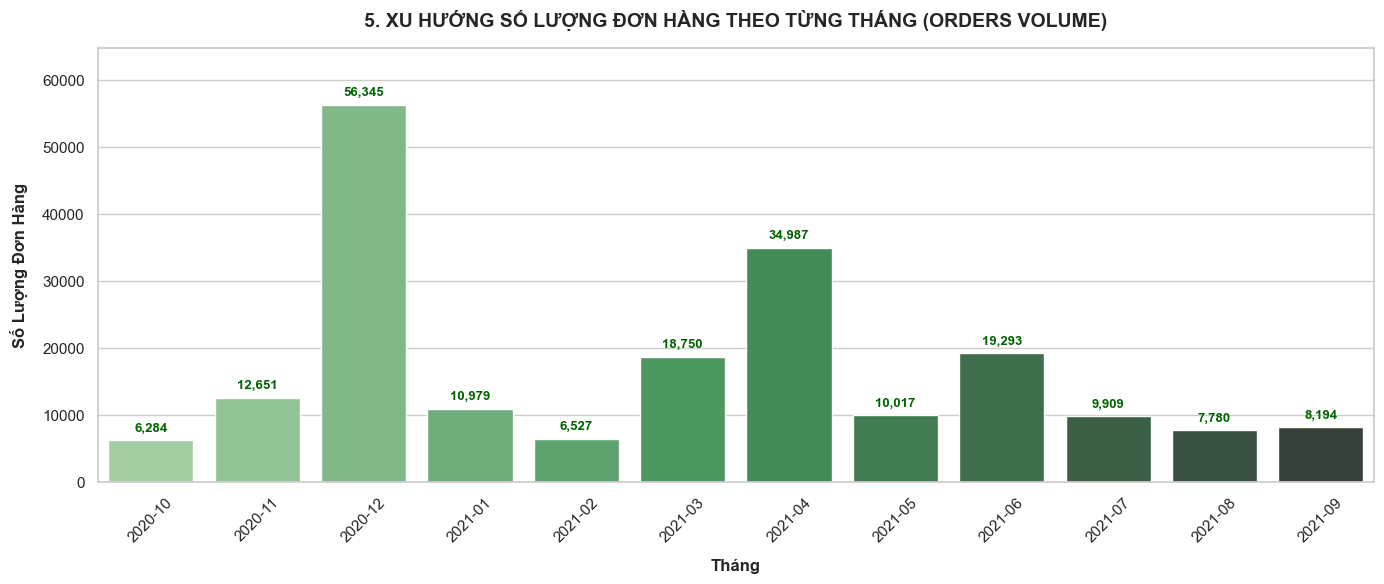

In [14]:
# Thiết lập giao diện
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# Khởi tạo khung hình độc lập cho Biểu đồ 5
plt.figure(figsize=(14, 6))

# Vẽ biểu đồ cột đứng thể hiện lượng đơn hàng phát sinh
ax5 = sns.barplot(
    data=df_monthly, 
    x='month_label', 
    y='orders', 
    hue='month_label', 
    palette='Greens_d', 
    legend=False
)

# Cấu hình tiêu đề và nhãn trục tọa độ
plt.title('5. XU HƯỚNG SỐ LƯỢNG ĐƠN HÀNG THEO TỪNG THÁNG (ORDERS VOLUME)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tháng', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Số Lượng Đơn Hàng', fontsize=12, fontweight='bold', labelpad=10)
plt.xticks(rotation=45)

# Bổ sung số liệu chính xác lên đầu mỗi cột đứng
for p in ax5.patches:
    val = p.get_height()
    if pd.notna(val) and val > 0:
        ax5.annotate(
            f"{int(val):,}", 
            (p.get_x() + p.get_width() / 2., val), 
            ha='center', va='bottom', 
            fontsize=9.5, fontweight='bold', color='darkgreen', 
            xytext=(0, 4), textcoords='offset points'
        )

# Tạo khoảng trống an toàn bên trên để nhãn số không bị tràn khung
plt.ylim(0, df_monthly['orders'].max() * 1.15)

plt.tight_layout()
plt.show()

## Biểu đồ 6

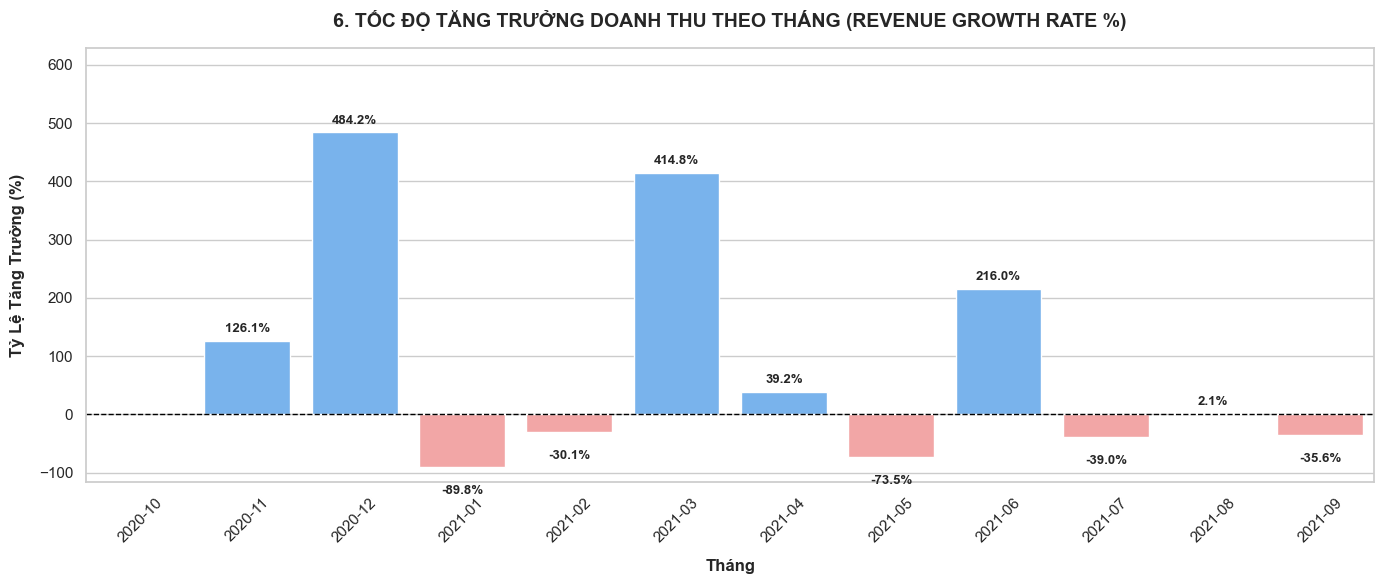

In [13]:
# Thiết lập giao diện
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# Khởi tạo khung hình độc lập cho Biểu đồ 6
plt.figure(figsize=(14, 6))

# Tự động gán màu thông minh: Đỏ đại diện cho tăng trưởng âm (<0), Xanh dương cho tăng trưởng dương (>=0)
colors = ['#ff9999' if x < 0 else '#66b3ff' for x in df_monthly['revenue_growth_rate'].fillna(0)]

# Vẽ biểu đồ cột âm dương
ax6 = sns.barplot(
    data=df_monthly, 
    x='month_label', 
    y='revenue_growth_rate', 
    hue='month_label', 
    palette=colors, 
    legend=False
)

# Thêm vạch kẻ nét đứt màu đen tại mốc 0% làm gốc đối chiếu
plt.axhline(0, color='black', linewidth=1, linestyle='--')

# Cấu hình tiêu đề và nhãn trục tọa độ
plt.title('6. TỐC ĐỘ TĂNG TRƯỞNG DOANH THU THEO THÁNG (REVENUE GROWTH RATE %)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tháng', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Tỷ Lệ Tăng Trưởng (%)', fontsize=12, fontweight='bold', labelpad=10)
plt.xticks(rotation=45)

# Bổ sung nhãn tỷ lệ phần trăm (%) tương ứng ở đầu hoặc dưới chân cột bar
for p in ax6.patches:
    val = p.get_height()
    if pd.notna(val) and val != 0:
        # Căn chỉnh vị trí chữ (trên hay dưới) tùy vào giá trị âm hay dương
        va_dir = 'bottom' if val >= 0 else 'top'
        xy_dir = (0, 4) if val >= 0 else (0, -13)
        ax6.annotate(
            f"{val:.1f}%", 
            (p.get_x() + p.get_width() / 2., val), 
            ha='center', va=va_dir, 
            fontsize=9.5, fontweight='bold', 
            xytext=xy_dir, textcoords='offset points'
        )

# Tối ưu hóa khoảng trần trục Y để không che khuất chữ của cột cao nhất và thấp nhất
y_max = df_monthly['revenue_growth_rate'].max()
y_min = df_monthly['revenue_growth_rate'].min()
plt.ylim(y_min * 1.3 if y_min < 0 else -10, y_max * 1.3 if y_max > 0 else 10)

plt.tight_layout()
plt.show()

# Total Revenue

In [1]:
import pandas as pd

df = pd.read_csv(
    r"D:\PRO2291_DuAnTopNghiep\PRO2291_duantotnghiep1\data\cleaned/sales_cleaned.csv",
    low_memory=False
)


In [2]:
total_revenue = df["total"].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $233,649,585.64


# Total Orders

In [3]:
total_orders = df["order_id"].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 201,715


# Total Customers

In [4]:
total_customers = df["cust_id"].nunique()

print(f"Total Customers: {total_customers:,}")

Total Customers: 64,248


# Average Order Value

In [5]:
aov = total_revenue / total_orders

print(f"AOV: ${aov:,.2f}")

AOV: $1,158.32
